In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../Dataset/student.csv')
df = df.drop(columns=['student_id', 'question_id', 'quiz_id', 'raw_row_index', 'topic', 'response_time'])

# encode dificulty as 0, 1, 2
difficulty_map = {'easy': 0, 'medium': 1, 'hard': 2}
df['difficulty'] = df['difficulty'].map(difficulty_map)
df.head()

,session_id,question_in_quiz,difficulty,accuracy_so_far,number_of_questions_answered_so_far,accuracy_easy_so_far,accuracy_medium_so_far,accuracy_hard_so_far,average_response_time_so_far,last_1_correctness,last_2_correctness,last_3_correctness,correct
0,0Hpj01paAdfZ_quiz_1,1,2,0.000000,0,0.000000,0.0,0.0,0.00,0,0,0,0
1,0Hpj01paAdfZ_quiz_1,2,0,0.000000,1,0.000000,0.0,0.0,24498.00,0,0,0,1
2,0Hpj01paAdfZ_quiz_1,3,0,0.500000,2,1.000000,0.0,0.0,16362.50,1,0,0,0
3,0Hpj01paAdfZ_quiz_1,4,0,0.333333,3,0.500000,0.0,0.0,16416.00,0,1,0,1
4,0Hpj01paAdfZ_quiz_1,5,1,0.500000,4,0.666667,0.0,0.0,15200.25,1,0,1,0


In [3]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, log_loss
import numpy as np

# Splitting data by session_id (70% train)
unique_sessions = df['session_id'].unique()
np.random.seed(42)
np.random.shuffle(unique_sessions)
split_idx = int(len(unique_sessions) * 0.7)

train_sessions = unique_sessions[:split_idx]
test_sessions = unique_sessions[split_idx:]

train_df = df[df['session_id'].isin(train_sessions)]
test_df = df[df['session_id'].isin(test_sessions)]

# Features and target (dropping session_id and the target variable 'correct')
X_train = train_df.drop(columns=['correct', 'session_id'])
y_train = train_df['correct']

X_test = test_df.drop(columns=['correct', 'session_id'])
y_test = test_df['correct']

# Train Model
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# Evaluate
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("AUC:", roc_auc_score(y_test, y_pred_proba))
print("LogLoss:", log_loss(y_test, y_pred_proba))

AUC: 0.8666290250795846
LogLoss: 0.36088641795798604


In [4]:
def simulate_adaptive_testing(test_df, model, k=5):
    results = []
    
    # Group by session_id
    grouped = test_df.groupby('session_id')
    
    # Feature columns expected by the model (excluding correct and session_id)
    feature_cols = [col for col in test_df.columns if col not in ['correct', 'session_id']]
    
    for session_id, group in grouped:
        # 2. Extract rows and sort by question_in_quiz
        session_data = group.sort_values('question_in_quiz').copy()
        
        # If session has fewer questions than k, we adjust k to max available
        actual_k = min(k, len(session_data))
        if actual_k == 0:
            continue
            
        full_score = session_data['correct'].mean()
        
        # 3. Initialize state
        correct_count = 0
        total_answered = 0
        accuracy_so_far = 0.0
        
        diff_answered = {0: 0, 1: 0, 2: 0} # easy: 0, medium: 1, hard: 2
        diff_correct = {0: 0, 1: 0, 2: 0}
        
        last_k_correct = [0, 0, 0]
        
        # 4. Pool of remaining questions
        pool = session_data.to_dict('records')
        
        for _ in range(actual_k):
            best_idx = -1
            min_dist = float('inf')
            
            # Predict for all remaining questions in the pool
            # We build the feature dataframe dynamically
            state_features = []
            for q in pool:
                # Construct feature dict ensuring no leakage.
                # Note: We must retain attributes like 'difficulty' from the question itself,
                # but overwrite dynamic features.
                feat_dict = {
                    'question_in_quiz': total_answered + 1,  # Now answering the nth question
                    'difficulty': q['difficulty'],
                    'accuracy_so_far': accuracy_so_far,
                    'number_of_questions_answered_so_far': total_answered,
                    'accuracy_easy_so_far': diff_correct[0] / diff_answered[0] if diff_answered[0] > 0 else 0.0,
                    'accuracy_medium_so_far': diff_correct[1] / diff_answered[1] if diff_answered[1] > 0 else 0.0,
                    'accuracy_hard_so_far': diff_correct[2] / diff_answered[2] if diff_answered[2] > 0 else 0.0,
                    'last_1_correctness': last_k_correct[-1],
                    'last_2_correctness': last_k_correct[-2],
                    'last_3_correctness': last_k_correct[-3]
                    # Response time variables removed completely to match original dropping of the 'response_time' column
                }
                
                # Ensure columns strictly match training features
                row_feats = {col: q.get(col, feat_dict.get(col, 0)) for col in feature_cols}
                row_feats.update({k_f: v_f for k_f, v_f in feat_dict.items() if k_f in feature_cols})
                
                state_features.append(row_feats)
                
            # Create DataFrame to feed to model
            X_pool = pd.DataFrame(state_features)[feature_cols] # ensure order matches
            
            # 5. Predict P(correct)
            probs = model.predict_proba(X_pool)[:, 1]
            
            # 6. Select question minimizing abs(P - 0.5) + diversity penalty
            dists = np.abs(probs - 0.5)
            
            # Penalty for overused difficulty
            penalties = np.array([0.1 * diff_answered[q['difficulty']] for q in pool])
            
            best_idx = np.argmin(dists + penalties)
            
            selected_q = pool[best_idx]
            
            # 7. Retrieve true label
            actual_correct = selected_q['correct']
            actual_diff    = selected_q['difficulty']
            
            # 8. Update student state
            total_answered += 1
            correct_count += actual_correct
            accuracy_so_far = correct_count / total_answered
            
            diff_answered[actual_diff] += 1
            diff_correct[actual_diff] += actual_correct
            
            last_k_correct.append(actual_correct)
            last_k_correct.pop(0)
            
            # 9. Remove from pool
            pool.pop(best_idx)
            
        # 10. Compute scores
        adaptive_score = correct_count / actual_k
        
        # 11. Store results
        results.append({
            'session_id': session_id,
            'full_score': full_score,
            'adaptive_score': adaptive_score,
            'k': actual_k
        })
        
    return pd.DataFrame(results)

# Optional: Test for different config values of k
k_values = [15, 20]
for k_val in k_values:
    print(f"Simulating adaptive test with k = {k_val}...")
    sim_results = simulate_adaptive_testing(test_df, model, k=k_val)
    print(sim_results.head())
    print("-" * 50)

Simulating adaptive test with k = 15...
            session_id  full_score  adaptive_score   k
0  0Hpj01paAdfZ_quiz_2    0.733333        0.600000  15
1  0rzpTGhVxVJU_quiz_1    0.700000        0.733333  15
2  0rzpTGhVxVJU_quiz_5    0.466667        0.400000  15
3  1ggBjCxnkaT8_quiz_4    0.700000        0.533333  15
4  1ggBjCxnkaT8_quiz_5    0.733333        0.666667  15
--------------------------------------------------
Simulating adaptive test with k = 20...
            session_id  full_score  adaptive_score   k
0  0Hpj01paAdfZ_quiz_2    0.733333            0.65  20
1  0rzpTGhVxVJU_quiz_1    0.700000            0.65  20
2  0rzpTGhVxVJU_quiz_5    0.466667            0.35  20
3  1ggBjCxnkaT8_quiz_4    0.700000            0.65  20
4  1ggBjCxnkaT8_quiz_5    0.733333            0.75  20
--------------------------------------------------


Pearson Correlation: 0.9379
Mean Absolute Error (MAE): 0.0704


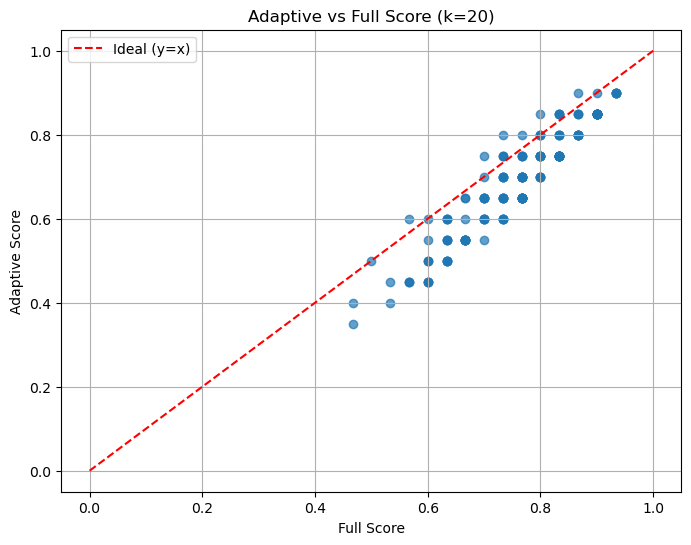

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr

# Assuming sim_results is the dataframe from the last simulation (k=20)
full_scores = sim_results['full_score']
adaptive_scores = sim_results['adaptive_score']

# 1) Pearson correlation
corr, p_value = pearsonr(full_scores, adaptive_scores)
print(f"Pearson Correlation: {corr:.4f}")

# 2) Mean Absolute Error (MAE)
mae = mean_absolute_error(full_scores, adaptive_scores)
print(f"Mean Absolute Error (MAE): {mae:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(full_scores, adaptive_scores, alpha=0.7)
plt.plot([0, 1], [0, 1], 'r--', label='Ideal (y=x)') # reference line
plt.title(f"Adaptive vs Full Score (k={sim_results['k'].iloc[0]})")
plt.xlabel("Full Score")
plt.ylabel("Adaptive Score")
plt.legend()
plt.grid(True)
plt.show()